#### UČITAVANJE PAKETA I PODATAKA

In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [3]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

# Ovaj kod nam služi samo za proveru
#print("Train dir:", train_dir.resolve())
#print("Test dir:", test_dir.resolve())

print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

#probati kasnije sa većim dimenzijama slike (128, 224) - bilo je značajno sporije izvršavanje
IMG_SIZE = 64 
BATCH_SIZE = 32

#probale smo DROPOUT_RATE = 0.5, ali je 0.3 dalo bolje rezultate (manji loss i veći accuracy na istom broju epoha)
DROPOUT_RATE = 0.3
VALIDATION_SPLIT = 0.2
SEED = 42
np.random.seed(SEED)

#na Windows-u na cpu je bilo znatno sporije treniranje (oko 12 epoha za 40 minuta :()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train exists: True
Test exists: True
Device: cpu


#### TRANSFORMACIJE SLIKA

CNN očekuje ulaz oblika (batch_size, channels, height, width). Koristimo `ToTensor` koji pretvara sliku u tensor i automatski skalira piksele iz opsega 0-255 u 0-1. U `Normalize` prosleđujemo standardnu normalizaciju često korišćenu za RGB slike. Takođe, zbog problema sa putanjama na Windows-u, dodajemo funkcije `add_windows_long_path_prefix` i `pil_loader_safe` (objašnjenje u komentarima).

In [97]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() moze da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogucava citanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraca obicnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [98]:
full_train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=transform,
    loader=pil_loader_safe
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(full_train_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


#### PODELA TRAIN SKUPA NA TRAIN I VALIDACIONI SKUP

Pošto poseban test skup nije dostupan, ideja je da koristimo originalni validacioni skup kao test skup za finalnu evaluaciju. Za validaciju tokom treniranja izdvajamo deo originalnog trening skupa.

In [99]:
val_size = int(len(full_train_dataset) * VALIDATION_SPLIT)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 2000
Test size: 1000


#### PRAVIMO DATALOADERE

Probati sa `num_workers` = 2 ili `num_workers` = 4, ukoliko sistem podržava za brže izvršavanje.

In [100]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### MODEL

Umesto velikog `Flatten` sloja koristmo `AdaptiveAvgPool2d`, koji svaku mapu karakteristika svodi na jednu vrednost. Time se smanjuje broj parametara u klasifikacionom delu modela i ubrzava treniranje, što nam je zgodno za baseline CNN model. Napomena: Sa `Flatten` verzijom iz prethodnog commit-a, izlaz prve epohe se nije pojavio ni nakon 2 sata.

Takođe, kao poslednju aktivacionu funkciju nismo stavile softmax, jer nam nisu potrebne verovatnoće, već možemo da radimo i sa sirovim podacima koje izbacuje `Linear` sloj.

In [101]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)  

        return x

In [102]:
model = BaselineCNN(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


#### TRENIRANJE

In [103]:
# probale smo manji broj epoha za početna testiranja i postepeno povećavale da proverimo da li dolazi do preprilagođavanja
EPOCHS = 20
LEARNING_RATE = 0.001

metrics = {
    "train_loss": [],
    "train_acc": [],
    "train_step": [],
    "val_loss": [],
    "val_acc": [],
    "val_step": []
}

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = np.inf
best_val_acc = 0.0
best_epoch = 0
best_model_state = None

training_step = 0
for epoch in range(EPOCHS):
    
    model.train()
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        predicted = torch.argmax(outputs, dim=1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / labels.size(0)
        metrics['train_loss'].append(loss.item())
        metrics['train_acc'].append(accuracy)
        metrics['train_step'].append(training_step)
        training_step += 1
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = 0
        val_correct = 0
        val_samples = 0
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = nn.functional.cross_entropy(outputs, labels, reduction='sum')
            val_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)
            val_correct += (predicted == labels).sum().item()
            val_samples += labels.size(0)

        val_loss /= val_samples
        val_accuracy = val_correct / val_samples
        metrics['val_loss'].append(val_loss)
        metrics['val_acc'].append(val_accuracy)
        metrics['val_step'].append(training_step)


    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train loss: {loss:.4f}, Train acc: {accuracy:.4f} | "
        f"Val loss: {val_loss:.4f}, Val acc: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_accuracy
        best_epoch = epoch + 1

        # Čuvamo najbolji model u memoriji, bez pisanja na disk u svakoj epohi.
        best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"  -> Novi najbolji model "
            f"(epoch {best_epoch}, val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})"
        )

print("\nTreniranje završeno.")
print(f"Najbolji model je iz epohe {best_epoch}")
print(f"Najbolji val_loss: {best_val_loss:.4f}")
print(f"Val_acc tog modela: {best_val_acc:.4f}")

# Vraćamo najbolje težine u model i čuvamo ih jednom na disk.
best_model_path = "baseline_cnn_best.pth"

if best_model_state is None:
    raise RuntimeError("Najbolji model nije sacuvan. Proveri trening petlju.")

model.load_state_dict(best_model_state)
model.to(device)
model.eval()

torch.save(model.state_dict(), best_model_path)
print(f"Najbolji model je sačuvan u: {best_model_path}")

Epoch [1/20] Train loss: 17.5703, Train acc: 0.6562 | Val loss: 1.1840, Val acc: 0.5880
  -> Novi najbolji model (epoch 1, val_loss=1.1840, val_acc=0.5880)
Epoch [2/20] Train loss: 9.7570, Train acc: 0.6562 | Val loss: 0.8177, Val acc: 0.7055
  -> Novi najbolji model (epoch 2, val_loss=0.8177, val_acc=0.7055)
Epoch [3/20] Train loss: 8.7902, Train acc: 0.6875 | Val loss: 0.6740, Val acc: 0.7675
  -> Novi najbolji model (epoch 3, val_loss=0.6740, val_acc=0.7675)
Epoch [4/20] Train loss: 4.8889, Train acc: 0.6875 | Val loss: 0.6117, Val acc: 0.7865
  -> Novi najbolji model (epoch 4, val_loss=0.6117, val_acc=0.7865)
Epoch [5/20] Train loss: 5.8585, Train acc: 0.8438 | Val loss: 0.5298, Val acc: 0.8230
  -> Novi najbolji model (epoch 5, val_loss=0.5298, val_acc=0.8230)
Epoch [6/20] Train loss: 4.2070, Train acc: 0.8125 | Val loss: 0.4755, Val acc: 0.8440
  -> Novi najbolji model (epoch 6, val_loss=0.4755, val_acc=0.8440)
Epoch [7/20] Train loss: 2.7457, Train acc: 0.9062 | Val loss: 0.4361

#### GRAFICI

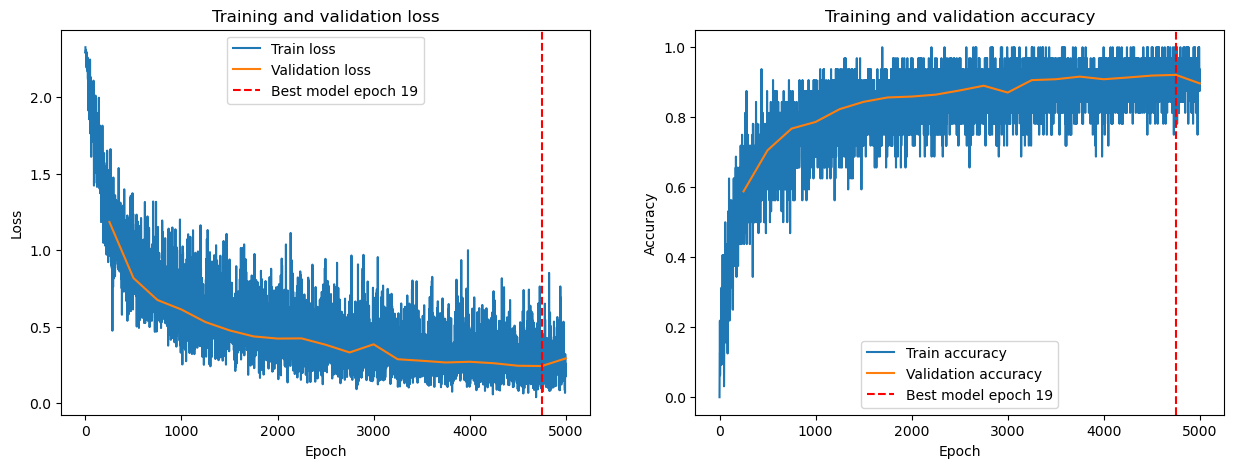

In [116]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(metrics["train_step"], metrics["train_loss"], label="Train loss")
plt.plot(metrics["val_step"], metrics["val_loss"], label="Validation loss")
best_step = metrics["val_step"][best_epoch - 1]
plt.axvline(best_step, linestyle="--", label=f"Best model epoch {best_epoch}", color='r')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(metrics["train_step"], metrics["train_acc"], label="Train accuracy")
plt.plot(metrics["val_step"], metrics["val_acc"], label="Validation accuracy")
best_step = metrics["val_step"][best_epoch - 1]
plt.axvline(best_step, linestyle="--", label=f"Best model epoch {best_epoch}", color='r')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.show()

#### EVALUACIJA NAJBOLJEG MODELA NA TEST SKUPU

Baseline CNN model sa tri konvoluciona sloja, global average pooling slojem i dropout regularizacijom postigao je test tačnost od 92.4%. Vidimo da model pokazuje stabilno učenje, jer trening i validacioni gubitak opadaju kroz epohe, dok tačnost raste. Najbolje se klasifikuju zdravi listovi i klasa Tomato mosaic virus, dok se najviše grešaka javlja između vizuelno sličnih bolesti, kao što su Early blight, Late blight, Leaf Mold i Spider mites/Target Spot.

In [108]:
model.eval()

total_loss = 0.0
total_correct = 0
total_samples = 0

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        _, predicted = torch.max(outputs, 1)

        total_loss += loss.item() * images.size(0)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

    avg_loss = total_loss / total_samples        
    accuracy = total_correct / total_samples
        

print(f"Test loss: {avg_loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.2781
Test accuracy: 0.9140


#### PRECISION, RECALL, F1-SCORE

Pošto su klase balansirane, `macro avg` i `weighted avg` su isti.
Najbolje vrednosti imaju klase:

- healthy: precision 0.97, recall 1.00, f1-score 0.99

- Tomato_mosaic_virus: precision 0.96, recall 0.94, f1-score 0.95

- Bacterial_spot: precision 0.89, recall 0.96, f1-score 0.92

Najslabije, ali i dalje solidne rezultate ima klasa:

- Late_blight: precision 0.88, recall 0.79, f1-score 0.83

To znači da se Late_blight najviše meša sa nekim drugim bolestima.

In [111]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names= [cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
))

                                      precision    recall  f1-score   support

                      Bacterial spot       0.89      0.96      0.92       100
                        Early blight       0.85      0.94      0.90       100
                         Late blight       0.88      0.79      0.83       100
                           Leaf Mold       0.87      0.92      0.89       100
                  Septoria leaf spot       0.90      0.87      0.88       100
Spider mites Two-spotted spider mite       0.95      0.89      0.92       100
                         Target Spot       0.94      0.96      0.95       100
       Tomato Yellow Leaf Curl Virus       0.95      0.87      0.91       100
                 Tomato mosaic virus       0.96      0.94      0.95       100
                             healthy       0.97      1.00      0.99       100

                            accuracy                           0.91      1000
                           macro avg       0.91      0.91     

#### MATRICA KONFUZIJE

Matrica konfuzije pokazuje da model dobro razlikuje većinu klasa.

Na dijagonali su tačne klasifikacije:

Bacterial_spot: 96/100  
Early_blight: 94/100  
Late_blight: 79/100  
Leaf_Mold: 92/100  
Septoria_leaf_spot: 87/100  
Spider_mites: 89/100  
Target_Spot: 96/100  
Yellow_Leaf_Curl_Virus: 87/100  
Tomato_mosaic_virus: 94/100  
healthy: 100/100  

Najveće greške koje se vide:
 
Spider_mites -> Target_Spot: 4 slike  
Yellow_Leaf_Curl_Virus -> Bacterial_spot: 9 slika  
Leaf_Mold -> Late_blight: 4 slike  
Late_blight -> Early_blight: 9 slika  
Septoria_leaf_spot -> Leaf_Mold: 5 slika 
Late_blight -> Leaf_Mold: 5 slika 
Spider_mites -> Mosaic_virus: 4 slike
Mosaic_virus -> Septoria_leaf_spot: 6 slika

Najbolje se klasifikuju zdravi listovi i klase Bacterial spot i Target spot, dok se najviše grešaka javlja između vizuelno sličnih bolesti, kao što su npr. Early blight i Late blight. Ovaj rezultat koristimo kao referentnu tačku za poređenje sa metric learning pristupom.

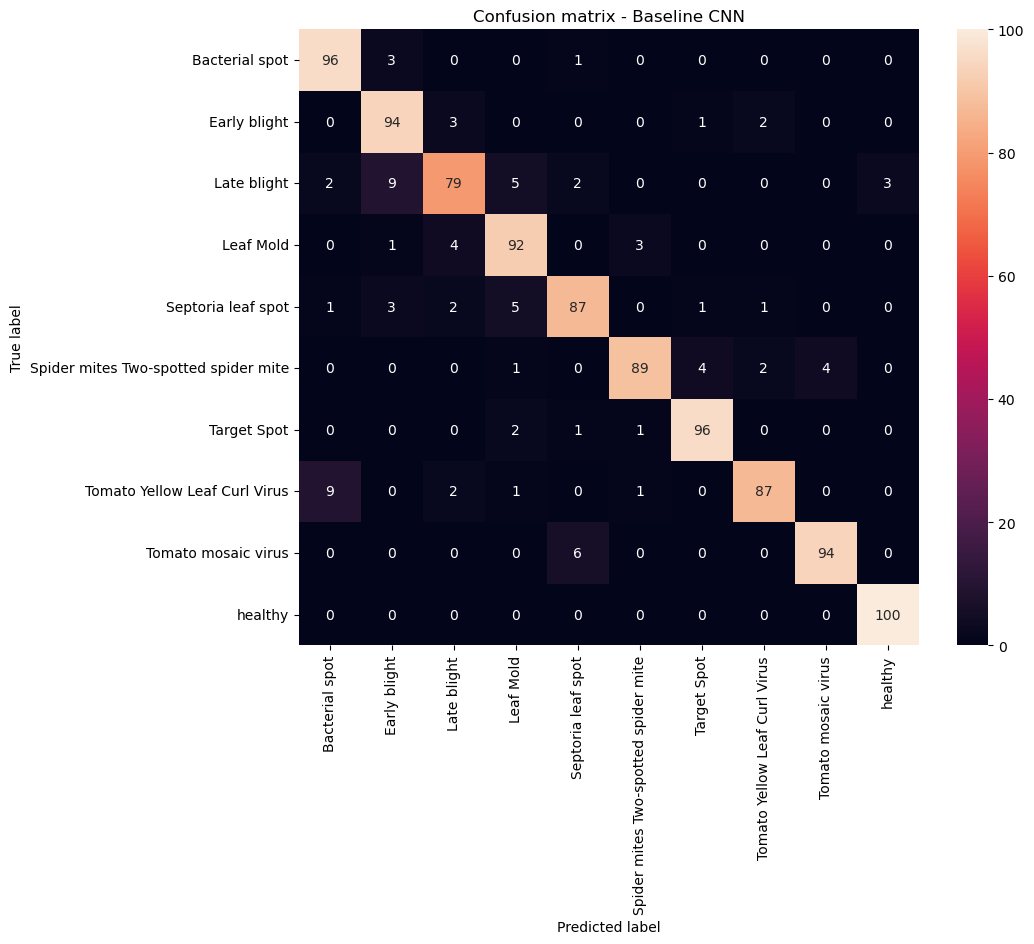

In [112]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Baseline CNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()